# Breast Cancer Prediction using KNN

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle

In [3]:
df = pd.read_csv("brca.csv")

In [4]:
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [5]:
df.tail()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
564,565,20.92,25.09,143.0,1347.0,0.10990,0.2236,0.31740,0.14740,0.2149,...,29.41,179.1,1819.0,0.1407,0.4186,0.6599,0.2542,0.2929,0.09873,M
565,566,21.56,22.39,142.0,1479.0,0.11100,0.1159,0.24390,0.13890,0.1726,...,26.40,166.1,2027.0,0.1410,0.2113,0.4107,0.2216,0.2060,0.07115,M
566,567,20.13,28.25,131.2,1261.0,0.09780,0.1034,0.14400,0.09791,0.1752,...,38.25,155.0,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.06637,M
567,568,16.60,28.08,108.3,858.1,0.08455,0.1023,0.09251,0.05302,0.1590,...,34.12,126.7,1124.0,0.1139,0.3094,0.3403,0.1418,0.2218,0.07820,M
568,569,20.60,29.33,140.1,1265.0,0.11780,0.2770,0.35140,0.15200,0.2397,...,39.42,184.6,1821.0,0.1650,0.8681,0.9387,0.2650,0.4087,0.12400,M


In [6]:
df.shape

(569, 32)

In [7]:
print("Number of Rows :",df.shape[0])

print("Number of Columns :",df.shape[1])

Number of Rows : 569
Number of Columns : 32


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,569.0,285.000000,164.400426,1.000000,143.000000,285.000000,427.000000,569.00000
x.radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
x.texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
x.perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
x.area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
x.smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
x.compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
x.concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
x.concave_pts_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
x.symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [9]:
df.isnull().sum()

Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [13]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [14]:
df.shape

(569, 31)

In [15]:
df["y"].value_counts()

y
B    357
M    212
Name: count, dtype: int64

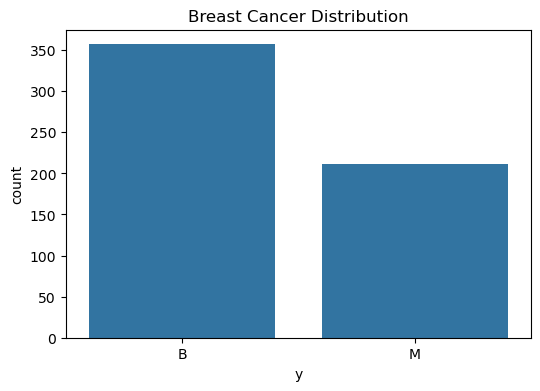

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="y",data=df)

plt.title("Breast Cancer Distribution")

plt.show()

In [17]:
df.dtypes

x.radius_mean          float64
x.texture_mean         float64
x.perimeter_mean       float64
x.area_mean            float64
x.smoothness_mean      float64
x.compactness_mean     float64
x.concavity_mean       float64
x.concave_pts_mean     float64
x.symmetry_mean        float64
x.fractal_dim_mean     float64
x.radius_se            float64
x.texture_se           float64
x.perimeter_se         float64
x.area_se              float64
x.smoothness_se        float64
x.compactness_se       float64
x.concavity_se         float64
x.concave_pts_se       float64
x.symmetry_se          float64
x.fractal_dim_se       float64
x.radius_worst         float64
x.texture_worst        float64
x.perimeter_worst      float64
x.area_worst           float64
x.smoothness_worst     float64
x.compactness_worst    float64
x.concavity_worst      float64
x.concave_pts_worst    float64
x.symmetry_worst       float64
x.fractal_dim_worst    float64
y                       object
dtype: object

In [18]:
for col in df.columns:

    print("="*50)

    print(col)

    print(df[col].unique())

x.radius_mean
[13.54  13.08   9.504 13.03   8.196 12.05  13.49  11.76  13.64  11.94
 11.52  13.05   8.618 10.17   8.598  9.173  9.465 11.31   9.029 12.78
  8.888 12.31  13.53  12.86  11.45  13.34  12.    12.36  14.64  14.62
 13.27  13.45  12.18   9.787 11.6    6.981  9.876 10.49  11.64  11.34
  9.777 12.63  14.26  10.51   8.726 11.93   8.95  11.41  14.5   13.37
 13.85  15.1   12.19  15.71  11.71  11.43  11.28   9.738 12.9   10.75
 11.9   14.95  14.44  13.74  13.     8.219  9.731 11.15  13.15  12.25
 16.84  12.06  10.9   11.75  12.34  14.97  10.8   12.32  11.08  10.66
  8.671  9.904 13.01  12.81  10.08  11.81  12.3   12.77   9.72  12.91
 12.23  12.47  13.11  15.27  11.84  11.89  10.2   13.65  13.56  10.18
 14.34  10.44  15.    12.62  11.32  11.22   9.567 14.03  14.22  12.42
 11.3   13.75  10.48  13.2   12.89  10.65  11.5   10.6   13.59  12.87
 10.71  14.29  11.29   9.742 11.33  11.74  12.58  11.26  11.37  14.41
 14.96  12.95  11.85  12.72  13.77  10.91  12.46  11.46   9.    13.5
 11.7  

In [19]:
le = LabelEncoder()

df["y"] = le.fit_transform(df["y"])

In [20]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,0
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,0
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,0
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,0
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,0


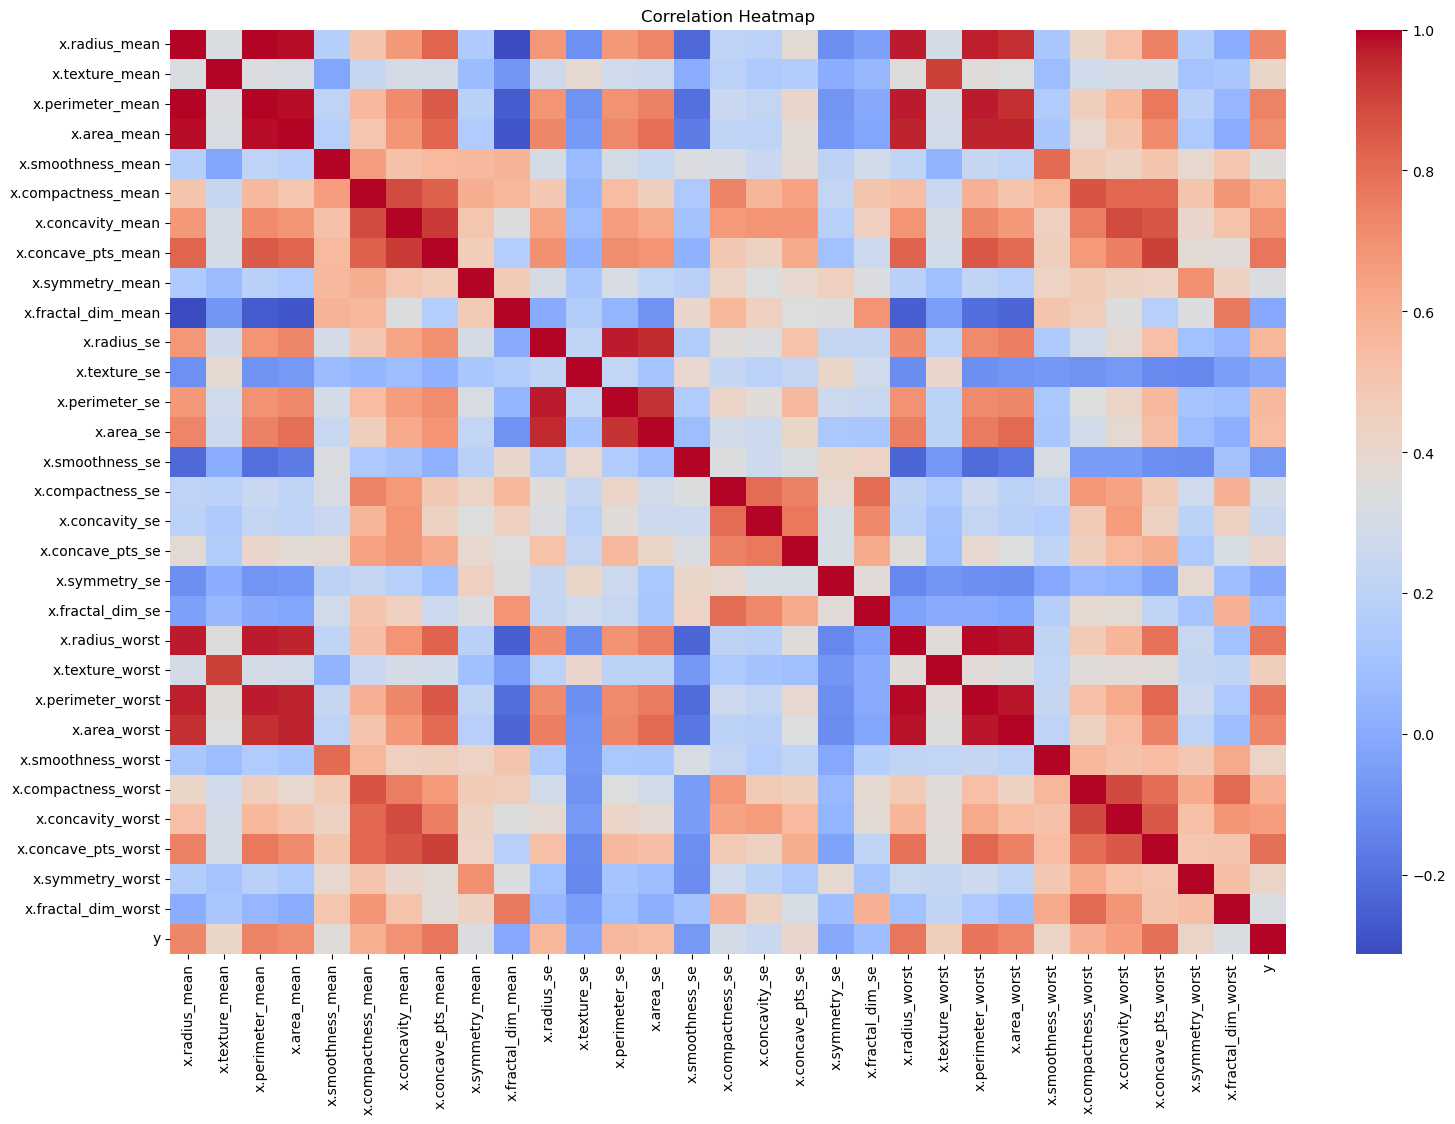

In [21]:
plt.figure(figsize=(18,12))

sns.heatmap(

df.corr(),

cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

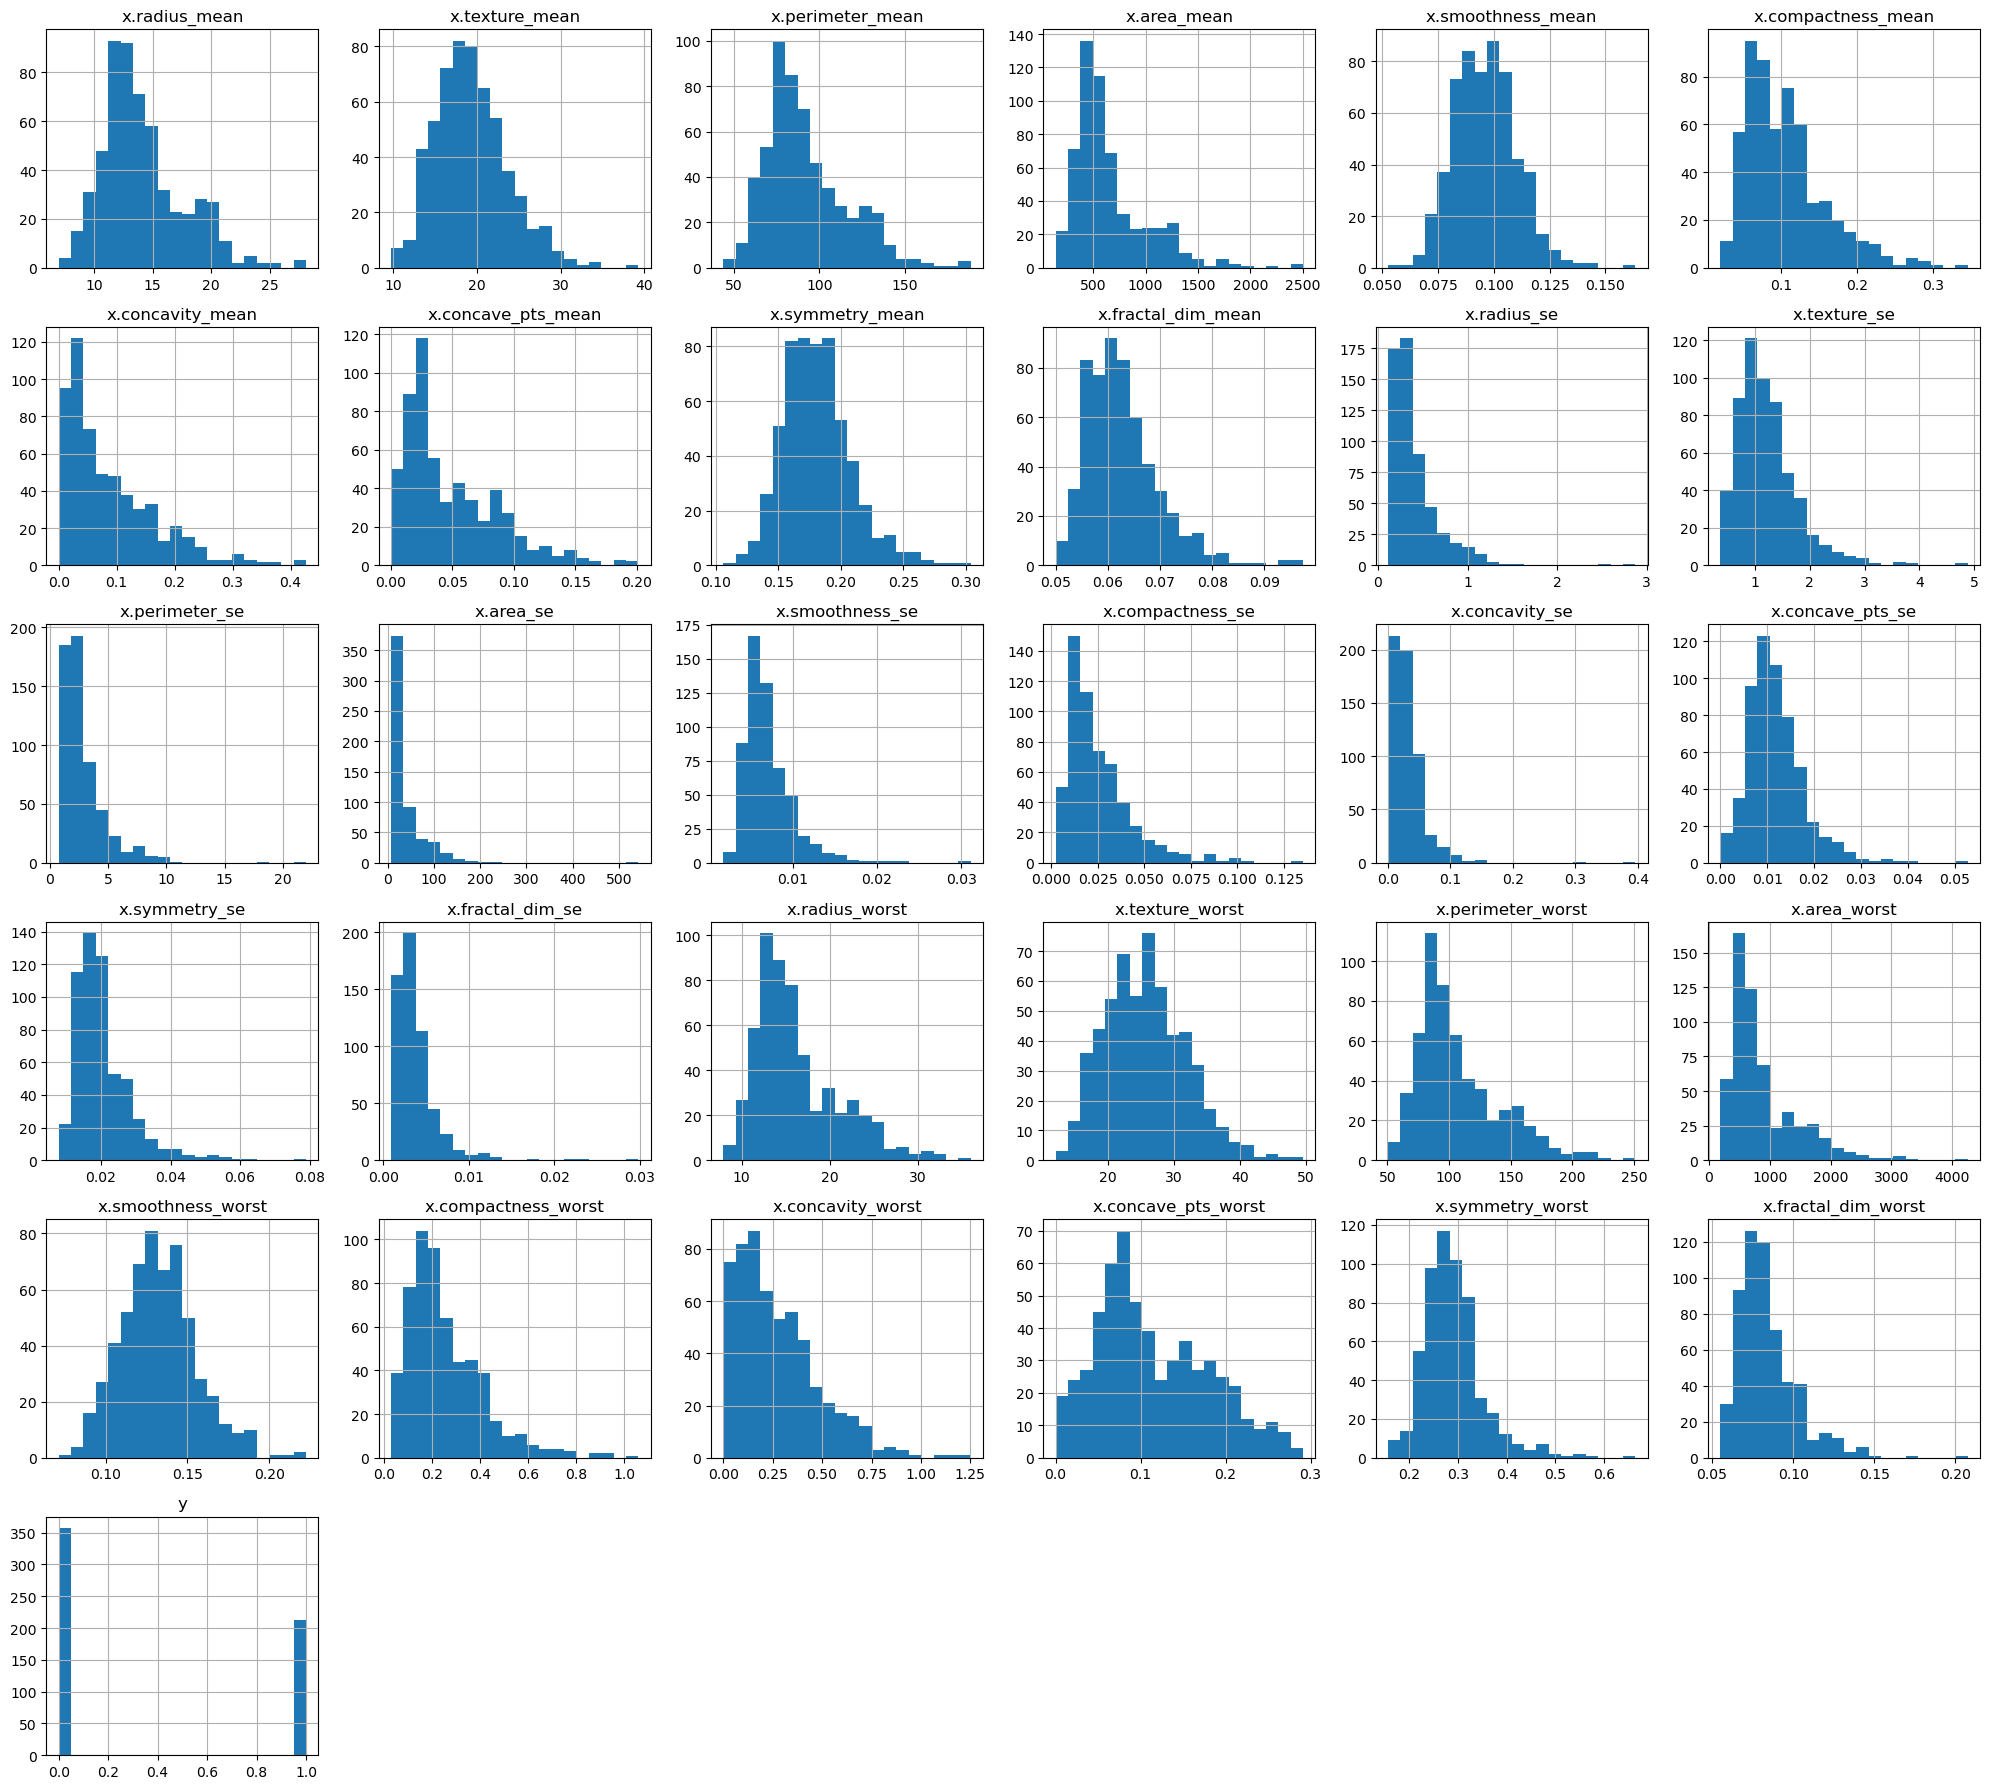

In [22]:
df.hist(

figsize=(20,18),

bins=20

)

plt.tight_layout()

plt.show()

In [23]:
correlation = df.corr()["y"].sort_values(ascending=False)

print(correlation)

y                      1.000000
x.concave_pts_worst    0.793566
x.perimeter_worst      0.782914
x.concave_pts_mean     0.776614
x.radius_worst         0.776454
x.perimeter_mean       0.742636
x.area_worst           0.733825
x.radius_mean          0.730029
x.area_mean            0.708984
x.concavity_mean       0.696360
x.concavity_worst      0.659610
x.compactness_mean     0.596534
x.compactness_worst    0.590998
x.radius_se            0.567134
x.perimeter_se         0.556141
x.area_se              0.548236
x.texture_worst        0.456903
x.smoothness_worst     0.421465
x.symmetry_worst       0.416294
x.texture_mean         0.415185
x.concave_pts_se       0.408042
x.smoothness_mean      0.358560
x.symmetry_mean        0.330499
x.fractal_dim_worst    0.323872
x.compactness_se       0.292999
x.concavity_se         0.253730
x.fractal_dim_se       0.077972
x.symmetry_se         -0.006522
x.texture_se          -0.008303
x.fractal_dim_mean    -0.012838
x.smoothness_se       -0.067016
Name: y,

In [24]:
correlation = df.corr()["y"].abs().sort_values(ascending=False)

print(correlation.head(10))

y                      1.000000
x.concave_pts_worst    0.793566
x.perimeter_worst      0.782914
x.concave_pts_mean     0.776614
x.radius_worst         0.776454
x.perimeter_mean       0.742636
x.area_worst           0.733825
x.radius_mean          0.730029
x.area_mean            0.708984
x.concavity_mean       0.696360
Name: y, dtype: float64


In [25]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,0
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,0
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,0
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,0
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 non-null    flo

In [27]:
X = df.drop("y", axis=1)

y = df["y"]

In [28]:
X.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409


In [29]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [30]:


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [31]:
print("Training Features :",X_train.shape)

print("Testing Features :",X_test.shape)

print()

print("Training Target :",y_train.shape)

print("Testing Target :",y_test.shape)

Training Features : (455, 30)
Testing Features : (114, 30)

Training Target : (455,)
Testing Target : (114,)


In [32]:
print("Training Data")

print(y_train.value_counts())

print()

print("Testing Data")

print(y_test.value_counts())

Training Data
y
0    285
1    170
Name: count, dtype: int64

Testing Data
y
0    72
1    42
Name: count, dtype: int64


In [33]:
scaler = StandardScaler()

In [34]:
X_train = scaler.fit_transform(X_train)

In [35]:
X_test = scaler.transform(X_test)

In [36]:
X_train

array([[ 0.51855873,  0.89182579,  0.4246317 , ..., -0.23574392,
         0.05456632,  0.02183673],
       [-0.51636409, -1.63971029, -0.54134872, ..., -0.32320788,
        -0.13757624, -0.90440164],
       [-0.36811839,  0.45551496, -0.38824993, ..., -0.89082504,
        -0.675893  , -0.14401559],
       ...,
       [-0.32616206,  1.33280304, -0.38905998, ..., -0.84289958,
        -0.96490082, -1.16888375],
       [ 0.00948859,  0.25952507,  0.00786279, ...,  0.27571059,
        -0.60284707, -0.30545988],
       [ 0.80945595,  0.36918608,  0.79320285, ...,  1.00657384,
        -0.46151907, -0.44817001]], shape=(455, 30))

In [37]:

np.std(X_train)

np.float64(1.0)

In [38]:
with open("scaler.pkl","wb") as file:

    pickle.dump(scaler,file)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [39]:
from sklearn.metrics import accuracy_score

In [40]:
train_accuracy = []

test_accuracy = []

k_values = range(1,21)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    train_pred = knn.predict(X_train)

    test_pred = knn.predict(X_test)

    train_accuracy.append(
        accuracy_score(y_train,train_pred)
    )

    test_accuracy.append(
        accuracy_score(y_test,test_pred)
    )

In [41]:
accuracy_table = pd.DataFrame({

    "K Value":list(k_values),

    "Training Accuracy":train_accuracy,

    "Testing Accuracy":test_accuracy

})

accuracy_table

,K Value,Training Accuracy,Testing Accuracy
0,1,1.000000,0.929825
1,2,0.973626,0.912281
2,3,0.984615,0.938596
3,4,0.978022,0.938596
4,5,0.978022,0.956140
5,6,0.964835,0.947368
6,7,0.971429,0.956140
7,8,0.967033,0.947368
8,9,0.973626,0.947368
9,10,0.967033,0.947368


In [42]:
best_k = accuracy_table.loc[
    accuracy_table["Testing Accuracy"].idxmax(),
    "K Value"
]

best_accuracy = accuracy_table["Testing Accuracy"].max()

print("Best K Value :",best_k)

print("Best Testing Accuracy :",round(best_accuracy*100,2),"%")

Best K Value : 5
Best Testing Accuracy : 95.61 %


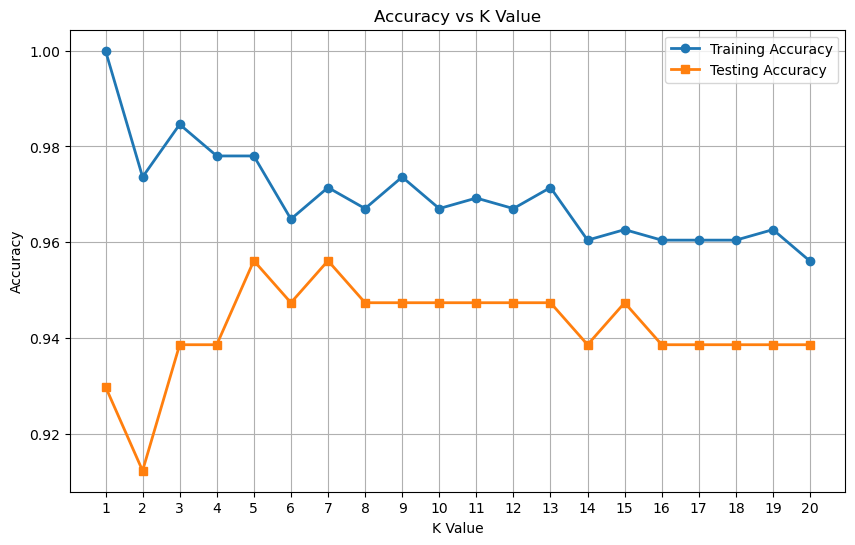

In [43]:
plt.figure(figsize=(10,6))

plt.plot(

    k_values,

    train_accuracy,

    marker='o',

    linewidth=2,

    label="Training Accuracy"

)

plt.plot(

    k_values,

    test_accuracy,

    marker='s',

    linewidth=2,

    label="Testing Accuracy"

)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K Value")

plt.xticks(range(1,21))

plt.grid(True)

plt.legend()

plt.show()

In [44]:
model = KNeighborsClassifier(

    n_neighbors=best_k

)

In [45]:
model

,n_neighbors,np.int64(5)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [47]:
model

,n_neighbors,np.int64(5)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
KNeighborsClassifier(n_neighbors=5)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
y_pred = model.predict(X_test)

In [50]:
print(y_pred)

[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [51]:
comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred

})

comparison.head(15)

,Actual,Predicted
49,0,0
481,1,1
207,0,0
421,1,0
269,0,0
169,0,0
392,1,1
205,0,0
34,0,0
306,0,0


In [52]:
probability = model.predict_proba(X_test)

probability[:10]

array([[1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [0.8, 0.2],
       [1. , 0. ],
       [1. , 0. ],
       [0.2, 0.8],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ]])

In [53]:
confidence = np.max(probability, axis=1)

confidence[:10]

array([1. , 1. , 1. , 0.8, 1. , 1. , 0.8, 1. , 1. , 1. ])

In [54]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 95.61 %


In [55]:
precision = precision_score(y_test, y_pred)

print("Precision :", round(precision*100,2),"%")

Precision : 97.44 %


In [56]:
recall = recall_score(y_test, y_pred)

print("Recall :", round(recall*100,2),"%")

Recall : 90.48 %


In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [58]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[71,  1],
       [ 4, 38]])

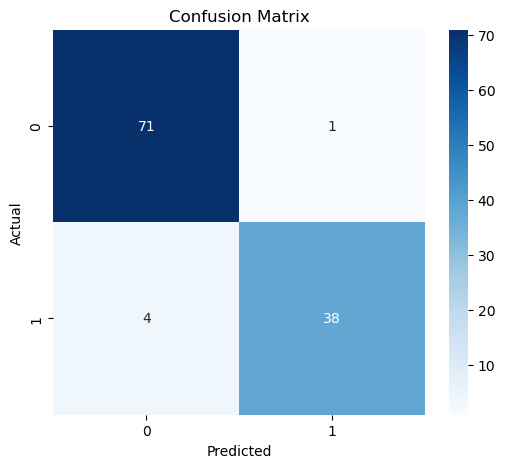

In [59]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

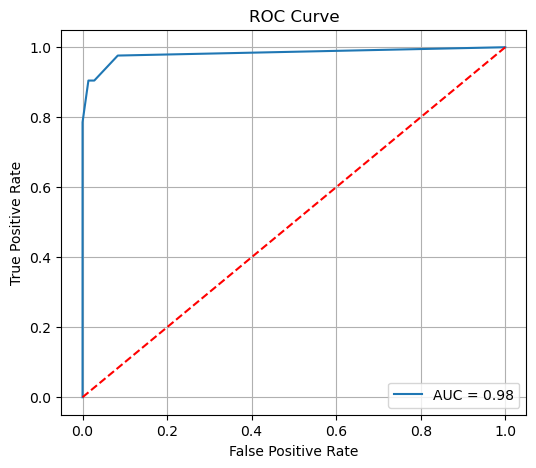

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.2f}"

)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [61]:
sample = np.array([[

17.99,
10.38,
122.8,
1001.0,
0.1184,
0.2776,
0.3001,
0.1471,
0.2419,
0.07871,
1.0950,
0.9053,
8.589,
153.4,
0.006399,
0.04904,
0.05373,
0.01587,
0.03003,
0.006193,
25.38,
17.33,
184.6,
2019.0,
0.1622,
0.6656,
0.7119,
0.2654,
0.4601,
0.11890

]])

In [62]:
sample = scaler.transform(sample)

In [63]:
prediction = model.predict(sample)

print(prediction)

[1]


In [64]:
if prediction[0] == 1:

    print("🔴 Malignant Cancer")

else:

    print("🟢 Benign Cancer")

🔴 Malignant Cancer


In [65]:
with open("model.pkl","wb") as file:

    pickle.dump(model,file)

print("Model Saved Successfully")

Model Saved Successfully


In [66]:
loaded_model = pickle.load(open("model.pkl","rb"))

loaded_model

,n_neighbors,np.int64(5)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [67]:
artifacts = {

    "model": model,

    "scaler": scaler,

    "best_k": best_k

}

with open("artifacts.pkl","wb") as file:

    pickle.dump(artifacts,file)

print("Artifacts Saved Successfully")

Artifacts Saved Successfully


In [68]:
artifacts = pickle.load(open("artifacts.pkl","rb"))

model = artifacts["model"]

scaler = artifacts["scaler"]

best_k = artifacts["best_k"]